Connected to Python 3.13.7

In [ ]:
### Automatic Review Analyzer
### Sentiment classification with Perceptron, Average Perceptron, and Pegasos

In [ ]:
### This script is structured like a notebook-style Python file.
### It keeps the original analysis code intact while adding short explanations
### between sections so the workflow is easier to follow.
###
### Expected project structure:
### - this script in the project root
### - source/project1.py
### - source/utils.py
### - source/data/...tsv files

In [ ]:
from source import project1 as p1
from source import utils
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
ROOT_DIR = Path(__file__).resolve().parent
DATA_DIR = ROOT_DIR / "source" / "data"

In [ ]:
### Load the training, validation, and test splits.
### Each review is represented by its text and sentiment label.

In [ ]:
#-------------------------------------------------------------------------------
# Data loading. There is no need to edit code in this section.
#-------------------------------------------------------------------------------

train_data = utils.load_data(DATA_DIR / 'reviews_train.tsv')
val_data = utils.load_data(DATA_DIR / 'reviews_val.tsv')
test_data = utils.load_data(DATA_DIR / 'reviews_test.tsv')

train_texts, train_labels = zip(*((sample['text'], sample['sentiment']) for sample in train_data))
val_texts, val_labels = zip(*((sample['text'], sample['sentiment']) for sample in val_data))
test_texts, test_labels = zip(*((sample['text'], sample['sentiment']) for sample in test_data))

In [ ]:
### Build a bag-of-words dictionary from the training texts and convert all
### review collections into feature matrices.

In [ ]:
# bag_of_words needs to first be implemented in project 1.py
dictionary = p1.bag_of_words(train_texts)

train_bow_features = p1.extract_bow_feature_vectors(train_texts, dictionary)
val_bow_features = p1.extract_bow_feature_vectors(val_texts, dictionary)
test_bow_features = p1.extract_bow_feature_vectors(test_texts, dictionary)

In [ ]:
### Start with a small 2D toy dataset.
### This makes it easy to visualize the decision boundaries learned by each method.

theta for Perceptron is 1.8809999999999982, 3.8159999999999963
theta_0 for Perceptron is -5.0


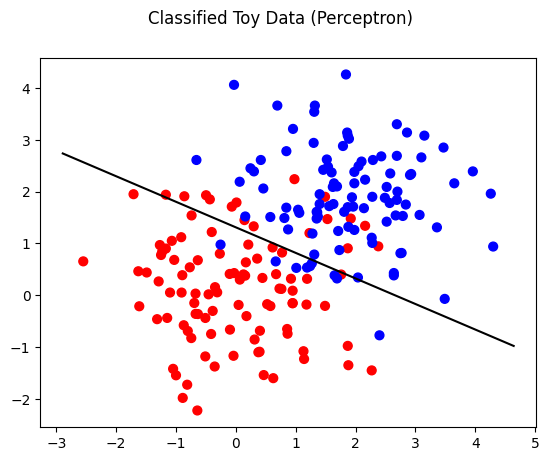

theta for Average Perceptron is 2.425476, 2.6097040000000176
theta_0 for Average Perceptron is -4.732


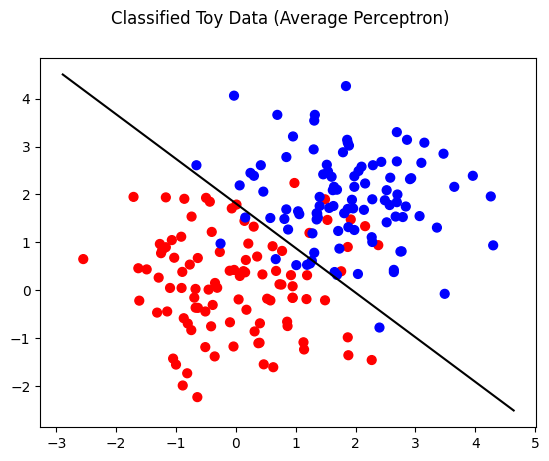

theta for Pegasos is 0.6878962360013456, 0.7620653856493942
theta_0 for Pegasos is -1.1216660077128084


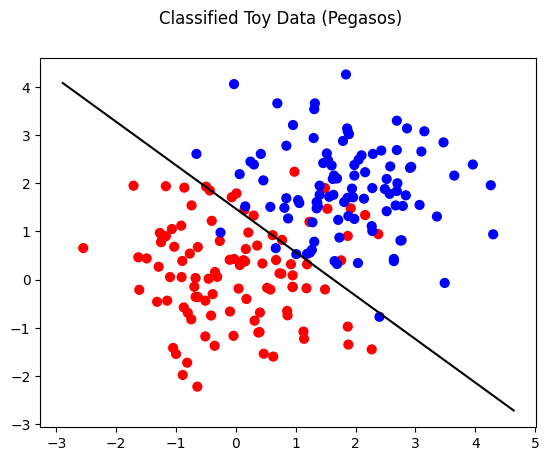

In [ ]:
#-------------------------------------------------------------------------------
# Problem 5
#-------------------------------------------------------------------------------

# Part 1: Plots

toy_features, toy_labels = toy_data = utils.load_toy_data(DATA_DIR / 'toy_data.tsv')

T = 10
L = 0.2

thetas_perceptron = p1.perceptron(toy_features, toy_labels, T)
thetas_avg_perceptron = p1.average_perceptron(toy_features, toy_labels, T)
thetas_pegasos = p1.pegasos(toy_features, toy_labels, T, L)

def plot_toy_results(algo_name, thetas):
    print('theta for', algo_name, 'is', ', '.join(map(str,list(thetas[0]))))
    print('theta_0 for', algo_name, 'is', str(thetas[1]))
    utils.plot_toy_data(algo_name, toy_features, toy_labels, thetas)

plot_toy_results('Perceptron', thetas_perceptron)
plot_toy_results('Average Perceptron', thetas_avg_perceptron)
plot_toy_results('Pegasos', thetas_pegasos)

In [ ]:
### Track how the parameters evolve as the number of passes increases.
### This gives a simple view of convergence behavior for the three algorithms.

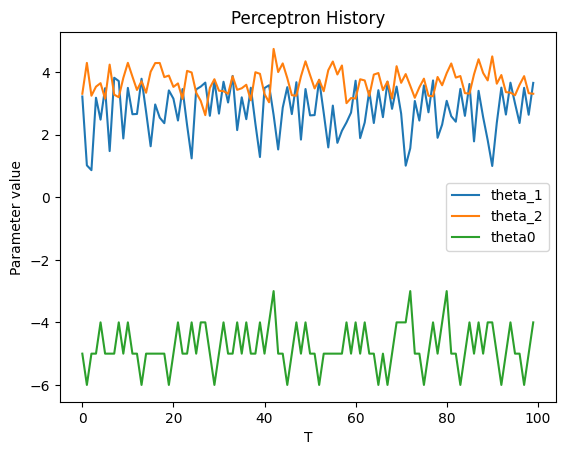

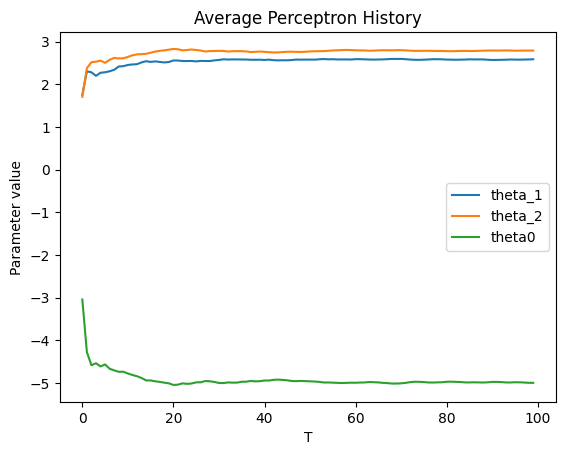

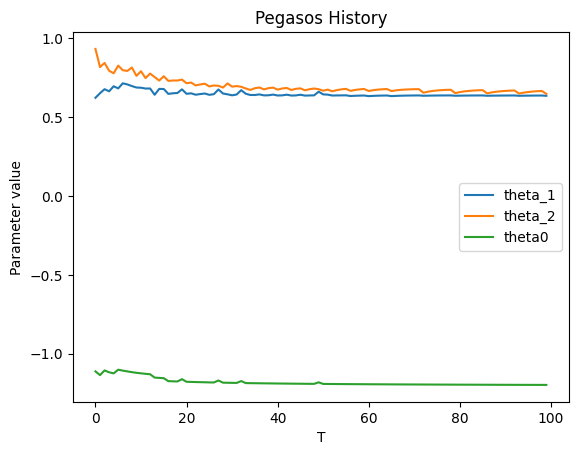

In [ ]:
# Part 2: Convergence

def perceptron_history(T_max):
    theta_history = []
    theta0_history = []
    for T in range(1, T_max+1):
        thetas = p1.perceptron(toy_features, toy_labels, T)
        theta_history.append(thetas[0])
        theta0_history.append(thetas[1])
    return theta_history, theta0_history

def average_perceptron_history(T_max):
    theta_history = []
    theta0_history = []
    for T in range(1, T_max+1):
        thetas = p1.average_perceptron(toy_features, toy_labels, T)
        theta_history.append(thetas[0])
        theta0_history.append(thetas[1])
    
    return theta_history, theta0_history

def pegasos_history(T_max, L):
    theta_history = []
    theta0_history = []
    for T in range(1, T_max+1):
        thetas = p1.pegasos(toy_features, toy_labels, T, L)
        theta_history.append(thetas[0])
        theta0_history.append(thetas[1])
    return theta_history, theta0_history

def plot_parameter_history(theta_history, theta0_history, title):
    theta_history = np.array(theta_history)   # shape (num_updates, 2)
    theta0_history = np.array(theta0_history) # shape (num_updates,)
    plt.figure()
    plt.plot(theta_history[:, 0], label='theta_1')
    plt.plot(theta_history[:, 1], label='theta_2')
    plt.plot(theta0_history, label='theta0')
    plt.xlabel('T')
    plt.ylabel('Parameter value')
    plt.title(title)
    plt.legend()
    plt.show()

T_max = 100
L = 0.2

theta_history, theta0_history = perceptron_history(T_max)
plot_parameter_history(theta_history, theta0_history, 'Perceptron History')

theta_history, theta0_history = average_perceptron_history(T_max)
plot_parameter_history(theta_history, theta0_history, 'Average Perceptron History')

theta_history, theta0_history = pegasos_history(T_max, L)
plot_parameter_history(theta_history, theta0_history, 'Pegasos History')

In [ ]:
### Compare the three algorithms on the full text dataset using a fixed set of
### hyperparameters. This gives a first baseline on training and validation data.

In [ ]:
#-------------------------------------------------------------------------------
# Problem 7
#-------------------------------------------------------------------------------

T = 10
L = 0.01

pct_train_accuracy, pct_val_accuracy = \
   p1.classifier_accuracy(p1.perceptron, train_bow_features,val_bow_features,train_labels,val_labels,T=T)
print("{:35} {:.4f}".format("Training accuracy for perceptron:", pct_train_accuracy))
print("{:35} {:.4f}".format("Validation accuracy for perceptron:", pct_val_accuracy))

avg_pct_train_accuracy, avg_pct_val_accuracy = \
   p1.classifier_accuracy(p1.average_perceptron, train_bow_features,val_bow_features,train_labels,val_labels,T=T)
print("{:43} {:.4f}".format("Training accuracy for average perceptron:", avg_pct_train_accuracy))
print("{:43} {:.4f}".format("Validation accuracy for average perceptron:", avg_pct_val_accuracy))

avg_peg_train_accuracy, avg_peg_val_accuracy = \
   p1.classifier_accuracy(p1.pegasos, train_bow_features,val_bow_features,train_labels,val_labels,T=T,L=L)
print("{:50} {:.4f}".format("Training accuracy for Pegasos:", avg_peg_train_accuracy))
print("{:50} {:.4f}".format("Validation accuracy for Pegasos:", avg_peg_val_accuracy))

Training accuracy for perceptron:   0.9293
Validation accuracy for perceptron: 0.7620
Training accuracy for average perceptron:   0.9770
Validation accuracy for average perceptron: 0.7960
Training accuracy for Pegasos:                     0.9042
Validation accuracy for Pegasos:                   0.7960


In [ ]:
### Tune the main hyperparameters.
### Perceptron and Average Perceptron are tuned over T, while Pegasos uses a
### grid over both T and lambda.

Best Perceptron: Accuracy = 0.7820, T=25.0000
Best Average Perceptron: Accuracy = 0.8020, T=15.0000
Best Pegasos: Accuracy = 0.8020, T=25, L=0.01


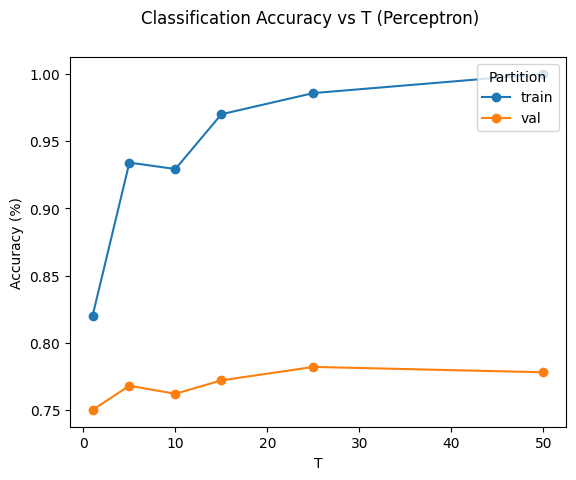

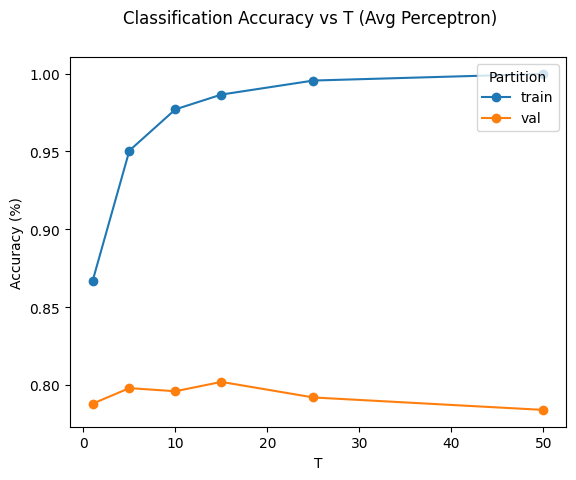

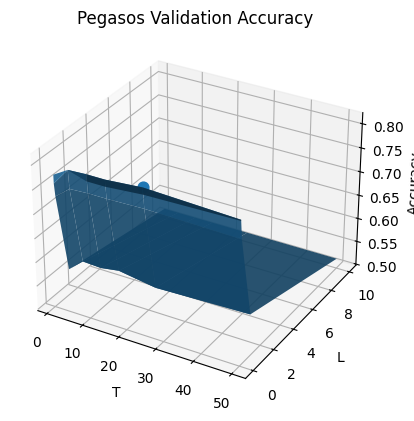

In [ ]:
#-------------------------------------------------------------------------------
# Problem 8
#-------------------------------------------------------------------------------

data = (train_bow_features, train_labels, val_bow_features, val_labels)

# values of T and lambda to try
Ts = [1, 5, 10, 15, 25, 50]
Ls = [0.001, 0.01, 0.1, 1, 10]

pct_tune_results = utils.tune_perceptron(Ts, *data)
print('Best Perceptron: Accuracy = {:.4f}, T={:.4f}'.format(np.max(pct_tune_results[1]), Ts[np.argmax(pct_tune_results[1])]))

avg_pct_tune_results = utils.tune_avg_perceptron(Ts, *data)
print('Best Average Perceptron: Accuracy = {:.4f}, T={:.4f}'.format(np.max(avg_pct_tune_results[1]), Ts[np.argmax(avg_pct_tune_results[1])]))

peg_train_accs, peg_val_accs, best_peg_T, best_peg_L = utils.tune_pegasos(Ts, Ls, *data)
print('Best Pegasos: Accuracy = {:.4f}, T={}, L={}'.format(np.max(peg_val_accs), best_peg_T, best_peg_L))


utils.plot_tune_results('Perceptron', 'T', Ts, *pct_tune_results)
utils.plot_tune_results('Avg Perceptron', 'T', Ts, *avg_pct_tune_results)
utils.plot_pegasos_3d(Ts, Ls, peg_val_accs, 'Pegasos Validation Accuracy')

In [ ]:
### Select the model with the strongest validation performance, retrain it on the
### training features, and evaluate it on the test set.

In [ ]:
#-------------------------------------------------------------------------------
# Use the best method (perceptron, average perceptron or Pegasos) along with
# the optimal hyperparameters according to validation accuracies to test
# against the test dataset. The test data has been provided as
# test_bow_features and test_labels.
#-------------------------------------------------------------------------------

best_pct = np.max(pct_tune_results[1])
best_avg_pct = np.max(avg_pct_tune_results[1])
best_peg = np.max(peg_val_accs)

method_accuracies = [best_pct, best_avg_pct, best_peg]
methods = ['Perceptron', 'Average Perceptron', 'Pegasos']

best_method = np.argmax(method_accuracies)

if best_method == 0:
    T = Ts[np.argmax(pct_tune_results[1])]
    theta, theta_0 = p1.perceptron(train_bow_features, train_labels, T)
elif best_method == 1:
    T = Ts[np.argmax(avg_pct_tune_results[1])]
    theta, theta_0 = p1.average_perceptron(train_bow_features, train_labels, T)
elif best_method == 2:
    T = best_peg_T
    L = best_peg_L
    theta, theta_0 = p1.pegasos(train_bow_features, train_labels, T, L)

predictions = p1.classify(test_bow_features, theta, theta_0)
test_accuracy = p1.accuracy(predictions, test_labels)
print(methods[best_method] + ': ' + str(test_accuracy))

Average Perceptron: 0.784


In [ ]:
### Inspect the largest positive and negative feature weights.
### These words provide a quick, interpretable summary of what the model has learned.

In [ ]:
#-------------------------------------------------------------------------------
# Assign to best_theta, the weights (and not the bias!) learned by your most
# accurate algorithm with the optimal choice of hyperparameters.
#-------------------------------------------------------------------------------

best_theta = theta
wordlist = [word for (idx, word) in sorted(zip(dictionary.values(), dictionary.keys()))]

sorted_word_features = utils.most_explanatory_word(best_theta, wordlist)
print("Most Explanatory Word Features")
print(sorted_word_features[:10])

sorted_word_features_neg = utils.most_explanatory_word(-best_theta, wordlist)
print("Most Explanatory Word Features for Negative Labels")
print(sorted_word_features_neg[:10])

Most Explanatory Word Features
['perfect', 'perfectly', 'delicious', 'glad', 'bottle', 'originally', 'protein', 'reasonable', 'pleased', 'great']
Most Explanatory Word Features for Negative Labels
['disappointment', 'worst', 'disappointed', 'unfortunately', 'horrible', 'awful', 'dont', 'including', 'ball', 'disgusting']


In [ ]:
### Try a simple feature-engineering variation by removing stopwords.
### Then compare binary bag-of-words features against count-based features.

In [ ]:
#-------------------------------------------------------------------------------
# Problem 9: Feature Engineering
#-------------------------------------------------------------------------------

dictionary = p1.bag_of_words(train_texts, remove_stopword=True)

# Remove Stop Words
train_bow_features = p1.extract_bow_feature_vectors(train_texts, dictionary)
test_bow_features = p1.extract_bow_feature_vectors(test_texts, dictionary)

T = 25; L = 0.01
theta, theta_0 = p1.pegasos(train_bow_features, train_labels, T, L)
predictions = p1.classify(test_bow_features, theta, theta_0)
test_accuracy = p1.accuracy(predictions, test_labels)
print('Pegasos with "stopwords" removed, Binary Features: ' + str(test_accuracy))

# Change Binary Features to Counts Features
train_bow_features = p1.extract_bow_feature_vectors(train_texts, dictionary, binarize=False)
test_bow_features = p1.extract_bow_feature_vectors(test_texts, dictionary, binarize=False)

T = 25; L = 0.01
theta, theta_0 = p1.pegasos(train_bow_features, train_labels, T, L)
predictions = p1.classify(test_bow_features, theta, theta_0)
test_accuracy = p1.accuracy(predictions, test_labels)
print('Pegasos with "stopwords" removed, Counts Features: ' + str(test_accuracy))

Pegasos with "stopwords" removed, Binary Features: 0.808
Pegasos with "stopwords" removed, Counts Features: 0.776
